# 01 · Overview & data quality

Discovers every EDF, parses the **experimental/control (E/C)** group from the file name, then
*derives* — rather than hard-codes — electrode status, crash tails and stage markers.
Uses only the committed `analysis` package (no hidden scripts).  Figures are also saved to
`reports/figures/` for the report.  Participant codes are replaced by neutral labels (exp1/exp2/ctrl1/ctrl2).

In [1]:
import warnings, pathlib, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

# Make the committed `analysis` package importable whether this notebook is
# launched from the repo root or from the notebooks/ folder.
_c = pathlib.Path.cwd()
REPO = next(p for p in [_c] + list(_c.parents) if (p / "analysis").is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis import dataset, eegkit as K

# Point DATA_DIR at any folder of EDFs named <subject><E|C><id>[_pN].edf
#   None -> repo data/  |  a path -> that folder  |  or set env EEG_DATA_DIR
DATA_DIR = None
recs = dataset.discover(DATA_DIR)

# Neutral per-recording labels (exp1, exp2, ctrl1, ctrl2) so participant codes
# never leak into figure titles / filenames.
_gi, LABEL = {}, {}
for _r in recs:
    _g = _r["group"]; _gi[_g] = _gi.get(_g, 0) + 1
    LABEL[_r["key"]] = ("exp" if _g == "E" else "ctrl") + str(_gi[_g])
def lbl(r): return LABEL[r["key"]]

FIG = REPO / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
IAF_DEF = 9.7

def ec_window(r):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0].startswith("rest_close")][0]

def get_iaf(r):
    raw = K.load(r["path"]); ec = ec_window(r)
    _, live = K.get(raw, ec[1], ec[2])
    return K.iaf(raw, live, ec[1], ec[2])

def stage_of(r, nm):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0] == nm]

print(f"discovered {len(recs)} recordings ->", {lbl(r): r["group"] for r in recs})
print("figures ->", str(FIG))


discovered 4 recordings -> {'exp1': 'E', 'exp2': 'E', 'ctrl1': 'C', 'ctrl2': 'C'}
figures -> /home/eugen/coding/ms-thesis/eeg-analysis/reports/figures


## 1. Electrode status per session
Dead channels = flat lines at the amplifier rail (no real ≥30 s live stretch anywhere).  Channels
that lived a real stretch then died/revived are **part** (mid-session).

In [2]:
status_rows = []
for r in recs:
    raw = K.load(r["path"])
    cs = K.channel_status(raw)
    status_rows.append(dict(recording=lbl(r), group=r["group"],
        n_eeg=len(K.eeg_channels(raw)),
        active=sum(v == "active" for v in cs.values()),
        dead=sum(v == "dead" for v in cs.values()),
        part=sum(v == "part" for v in cs.values()),
        crash_trim=K.trim_time(raw)))
print(pd.DataFrame(status_rows).to_string(index=False))
print("\nSame dead ring across all sessions -> a hardware problem, not preparation.")


recording group  n_eeg  active  dead  part  crash_trim
     exp1     E     36      24    10     2         NaN
     exp2     E     36      24    11     1         NaN
    ctrl1     C     36      23    12     1      1394.0
    ctrl2     C     36      23    13     0         NaN

Same dead ring across all sessions -> a hardware problem, not preparation.


## 2. Top view of the dead electrodes
Grey = active, red x = dead whole session, orange circle = changed state mid-session.

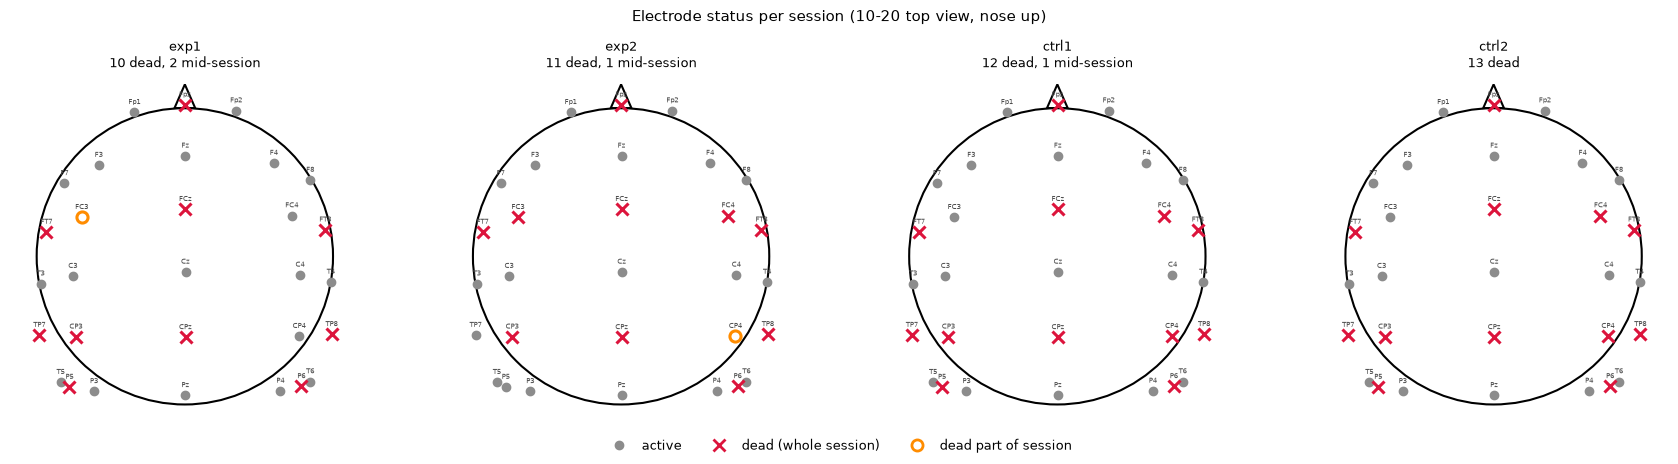

In [3]:
import mne, matplotlib.patches as mpatches
MON = mne.channels.make_standard_montage("standard_1020")
_raw = MON.get_positions()["ch_pos"]
_r = np.median([np.hypot(v[0], v[1]) for v in _raw.values()])
pos = {k.lower(): np.array(v) / _r for k, v in _raw.items()}

fig, axes = plt.subplots(1, len(recs), figsize=(4.4 * len(recs), 4.6))
axes = np.atleast_1d(axes)
for ax, r in zip(axes, recs):
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_xlim(-1.18, 1.18); ax.set_ylim(-1.12, 1.22)
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, lw=1.5, color="k"))
    ax.add_patch(mpatches.Polygon([[-0.07, 1.0], [0.07, 1.0], [0, 1.16]], lw=1.5, fill=False))
    raw = K.load(r["path"]); cs = K.channel_status(raw)
    for ch in K.eeg_channels(raw):
        p = pos.get(ch.lower())
        if p is None: continue
        stt = cs[ch]
        if stt == "dead":    ax.plot(p[0], p[1], "x", ms=9, mew=2.2, color="crimson", zorder=3)
        elif stt == "part":  ax.plot(p[0], p[1], "o", ms=8, mfc="none", mec="darkorange", mew=2.2, zorder=3)
        else:                ax.plot(p[0], p[1], "o", ms=6, color="0.55")
        ax.annotate(ch, (p[0], p[1]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=5.2, color="0.3")
    n_dead = sum(v == "dead" for v in cs.values()); n_part = sum(v == "part" for v in cs.values())
    ax.set_title(lbl(r) + f"\n{n_dead} dead" + (f", {n_part} mid-session" if n_part else ""), fontsize=9)
h = [plt.Line2D([], [], marker="o", ls="", ms=6, color="0.55", label="active"),
     plt.Line2D([], [], marker="x", ls="", ms=8, mew=2, color="crimson", label="dead (whole session)"),
     plt.Line2D([], [], marker="o", ls="", ms=8, mfc="none", mec="darkorange", mew=2, label="dead part of session")]
fig.legend(handles=h, loc="lower center", ncol=3, frameon=False, fontsize=9)
fig.suptitle("Electrode status per session (10-20 top view, nose up)", fontsize=11)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig(FIG / "dead_topomaps.png", dpi=150)
plt.show(); plt.close(fig)


## 3. What a dead channel looks like

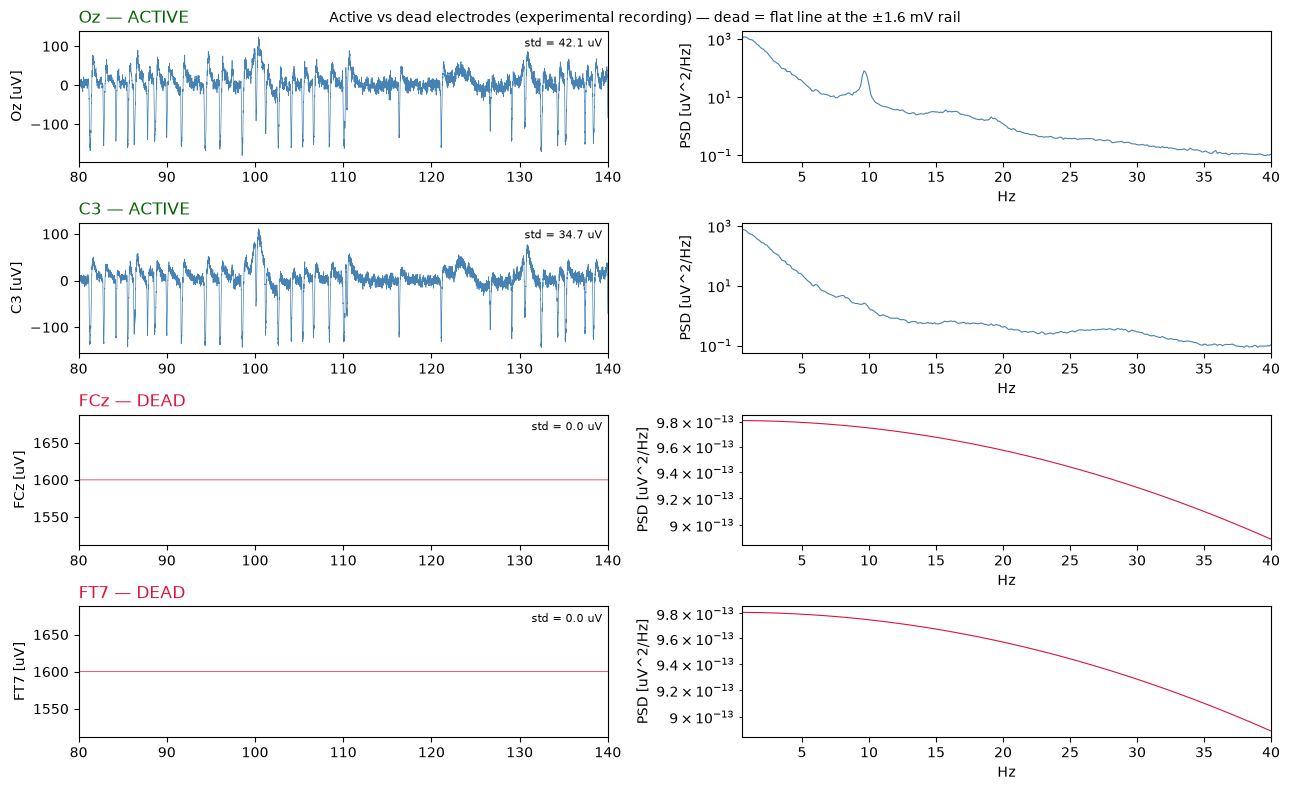

In [4]:
r = recs[0]; raw = K.load(r["path"]); fs = raw.info["sfreq"]; x = raw.get_data()
sd = K.static_dead(raw)
dead = [c for c in ("FCz", "FT7") if c in sd][:2] or sd[:2]
act = [c for c in ("Oz", "C3") if c in K.live_channels(raw)][:2]
t0, t1 = 80, 140; sl = slice(int(t0 * fs), int(t1 * fs))
from scipy.signal import welch
fig, axes = plt.subplots(len(act) + len(dead), 2, figsize=(13, 8))
rows = [(c, "ACTIVE") for c in act] + [(c, "DEAD") for c in dead]
for i, (ch, kind) in enumerate(rows):
    d = x[raw.ch_names.index(ch)][sl] * 1e6
    col = "crimson" if kind == "DEAD" else "steelblue"
    tt = np.arange(sl.stop - sl.start) / fs + t0
    ax = axes[i, 0]; ax.plot(tt, d, lw=0.5, color=col)
    ax.set_ylabel(f"{ch} [uV]"); ax.set_xlim(t0, t1)
    ax.set_title(f"{ch} — {kind}", loc="left", color="crimson" if kind == "DEAD" else "darkgreen")
    ax.text(0.99, 0.95, f"std = {d.std():.1f} uV", transform=ax.transAxes, ha="right", va="top", fontsize=8)
    f, p = welch(x[raw.ch_names.index(ch)] * 1e6, fs=fs, nperseg=8 * fs)
    m = (f >= 0.5) & (f <= 40)
    ax = axes[i, 1]; ax.semilogy(f[m], p[m], lw=0.8, color=col)
    ax.set_xlim(0.5, 40); ax.set_ylabel("PSD [uV^2/Hz]"); ax.set_xlabel("Hz")
fig.tight_layout()
fig.suptitle("Active vs dead electrodes (experimental recording) — dead = flat line at the ±1.6 mV rail", fontsize=10)
fig.savefig(FIG / "dead_vs_active.png", dpi=110); plt.show(); plt.close(fig)


## 4. Auxiliary channels (breathing belt, Resp2, GSR)
The control's recording crashed and resumed, so it has two parts.  Zoom representative windows
(belt + GSR are real; Resp2 was never connected → noise).

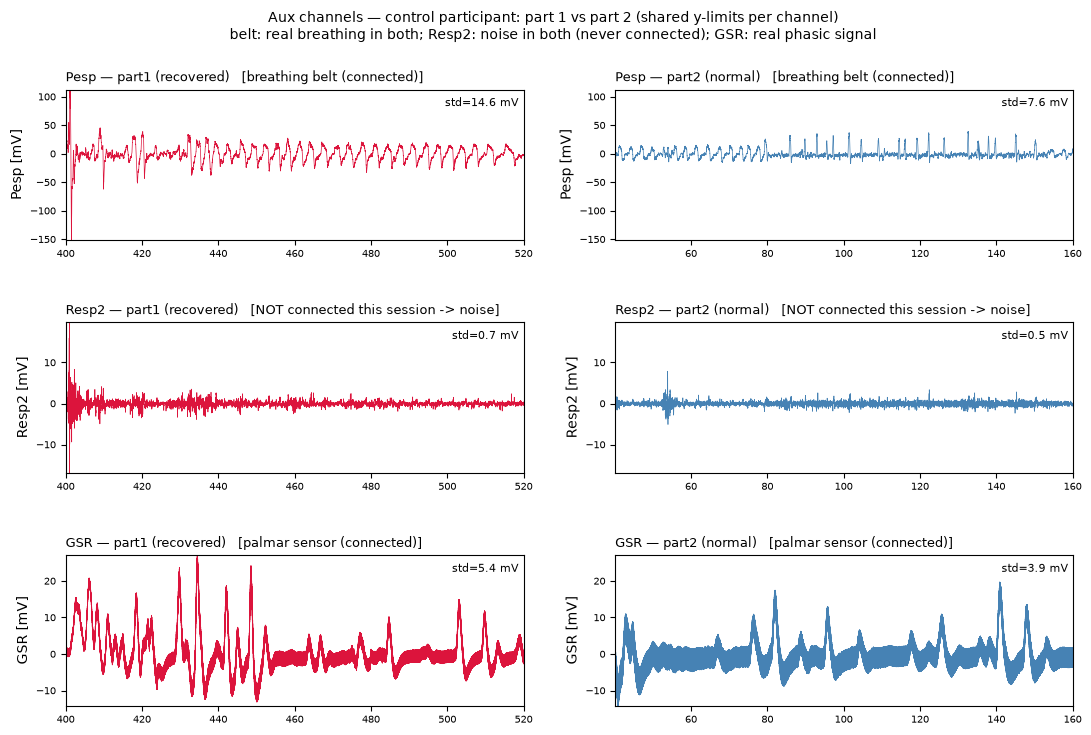

  saved aux figure (control ctrl1 vs ctrl2), windows p1=(400.0, 520.0) p2=(40.128, 160.128)


In [5]:
by_subject = {}
for r in recs: by_subject.setdefault(r["subject"], []).append(r)
pair = next((v for v in by_subject.values() if len(v) >= 2 and v[0]["group"] == "C"), None)
if pair is None:
    print("No two-part recording found; skipping aux figure.")
else:
    r1, r2 = pair[0], sorted(pair, key=lambda r: (r["part"] or 0))[-1]
    raw1, raw2 = K.load(r1["path"]), K.load(r2["path"])
    fs1, fs2 = raw1.info["sfreq"], raw2.info["sfreq"]
    x1, x2 = raw1.get_data(), raw2.get_data()
    st1 = K.get_stages(raw1, r1["key"]); st2 = K.get_stages(raw2, r2["key"])
    hv1 = [s for s in st1 if s[0] == "hypervent"]; sp2 = [s for s in st2 if s[0] == "speech"]
    if hv1 and sp2:
        W1 = (hv1[0][1], min(hv1[0][1] + 120, hv1[0][2]))
        W2 = (sp2[0][1], min(sp2[0][1] + 120, sp2[0][2]))
    else:
        W1, W2 = (60, 180), (40, 160)
    NOTES = [("Pesp", "breathing belt (connected)"),
             ("Resp2", "NOT connected this session -> noise"),
             ("GSR", "palmar sensor (connected)")]
    CHS = [(c, n) for c, n in NOTES if c in raw1.ch_names and c in raw2.ch_names]
    fig, axes = plt.subplots(len(CHS), 2, figsize=(13, 8)); fig.subplots_adjust(hspace=0.55)
    for row, (ch, note) in enumerate(CHS):
        d1 = x1[raw1.ch_names.index(ch)]; d2 = x2[raw2.ch_names.index(ch)]
        s1 = d1[int(W1[0] * fs1):int(W1[1] * fs1)] * 1e3
        s2 = d2[int(W2[0] * fs2):int(W2[1] * fs2)] * 1e3
        ylim = (min(s1.min(), s2.min()), max(s1.max(), s2.max()))
        for col, (s, fs_, w, fname) in enumerate([(s1, fs1, W1, "part1 (recovered)"),
                                                  (s2, fs2, W2, "part2 (normal)")]):
            ax = axes[row, col]; tt = np.arange(len(s)) / fs_ + w[0]
            ax.plot(tt, s, lw=0.5, color="crimson" if col == 0 else "steelblue")
            ax.set_ylim(ylim); ax.set_xlim(w); ax.set_ylabel(f"{ch} [mV]"); ax.tick_params(labelsize=7)
            ax.set_title(f"{ch} — {fname}   [{note}]", fontsize=9, loc="left")
            ax.text(0.99, 0.95, f"std={np.std(s):.1f} mV", transform=ax.transAxes, ha="right", va="top", fontsize=8)
    fig.suptitle("Aux channels — control participant: part 1 vs part 2 (shared y-limits per channel)\n"
                 "belt: real breathing in both; Resp2: noise in both (never connected); GSR: real phasic signal", fontsize=10)
    fig.savefig(FIG / "aux_ctrl_parts.png", dpi=110); plt.show(); plt.close(fig)
    print(f"  saved aux figure (control {lbl(r1)} vs {lbl(r2)}), windows p1={W1} p2={W2}")


## 5. Stage markers

In [6]:
rows = []
for r in recs:
    raw = K.load(r["path"])
    mk = K.stages_from_markers(raw); ev = K.event_times(raw)
    n_ov = r["key"] in dataset.STAGE_OVERRIDES
    meth = "markers" if len(mk) >= 3 else ("override" if n_ov else "estimate")
    st = K.get_stages(raw, r["key"])
    rows.append(dict(recording=lbl(r), events=len(ev), marker_stages=len(mk), method=meth,
                     stage_durations=[round(s[2] - s[1], 1) for s in st]))
print(pd.DataFrame(rows).to_string(index=False))
print("\nFixed protocol stages should be ~180 s; free stages (reading/speech) vary.")


recording  events  marker_stages   method                                                 stage_durations
     exp1      15              9  markers [180.0, 180.0, 180.0, 180.0, 182.4, 180.0, 371.8, 180.0, 180.9]
     exp2      14              8  markers        [180.0, 180.0, 180.0, 180.0, 180.0, 347.5, 180.0, 181.0]
    ctrl1       0              0 override               [150.0, 190.0, 180.0, 180.0, 180.0, 180.0, 265.0]
    ctrl2       5              3  markers                                           [373.5, 180.0, 181.0]

Fixed protocol stages should be ~180 s; free stages (reading/speech) vary.


## 6. Alpha reactivity & spectra (validity)
Eyes-closed occipital alpha (cyan) dominates the spectrum; eyes-open is suppressed.

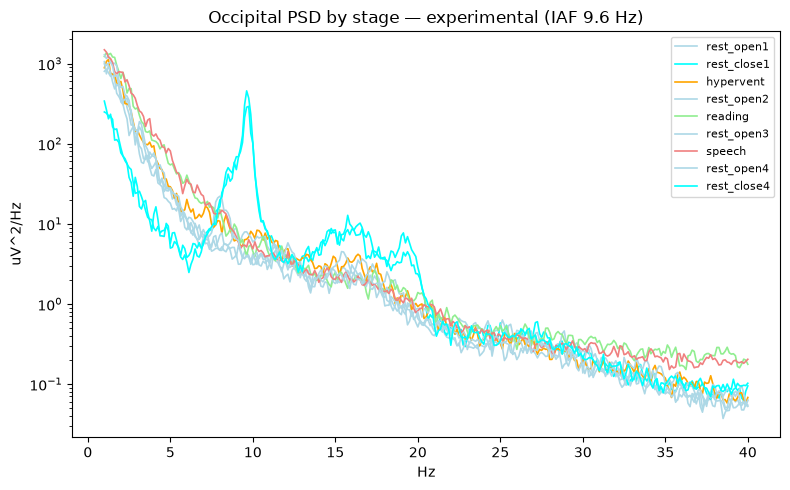

  exp1: IAF 9.6 Hz, eyes-closed/open alpha ratio = 18.0x


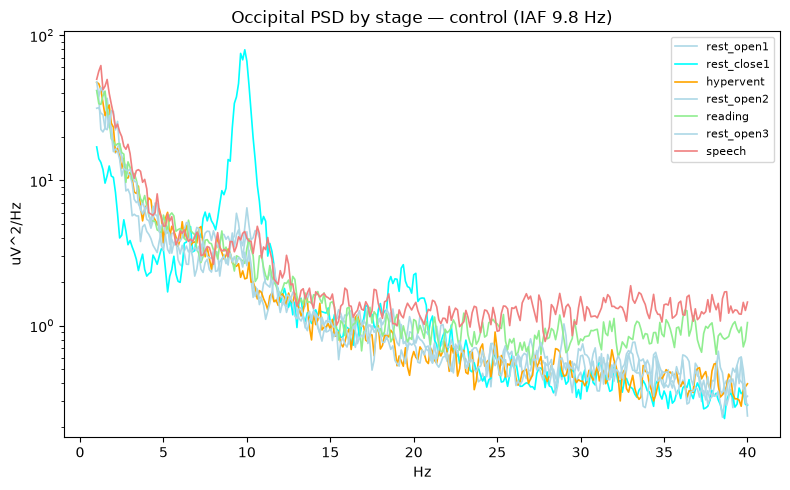

  ctrl1: IAF 9.8 Hz, eyes-closed/open alpha ratio = 6.8x


In [7]:
STAGE_COLORS = {"rest_open": "lightblue", "rest_close": "cyan", "hypervent": "orange",
                "reading": "lightgreen", "speech": "lightcoral"}
def _col(nm):
    for k, v in STAGE_COLORS.items():
        if nm.startswith(k): return v
    return "grey"
exp = recs[0]
ctrl = next(r for r in recs if r["group"] == "C" and not r["part"])
for r, tag in ((exp, "exp"), (ctrl, "ctrl")):
    raw = K.load(r["path"]); fs = raw.info["sfreq"]; IAF = get_iaf(r)
    st = K.get_stages(raw, r["key"])
    occ = [raw.ch_names.index(c) for c in K.OCCIP if c in raw.ch_names]
    from scipy.signal import welch
    fig, ax = plt.subplots(figsize=(8, 5))
    for nm, a, b in st:
        seg = raw.get_data()[occ][:, int(a * fs):int(b * fs)].mean(0)
        f, p = welch(seg * 1e6, fs=fs, nperseg=8 * fs)
        m = (f >= 1) & (f <= 40)
        ax.semilogy(f[m], p[m], lw=1.2, color=_col(nm), label=nm)
    ax.set_xlabel("Hz"); ax.set_ylabel("uV^2/Hz"); ax.legend(fontsize=8)
    ax.set_title(f"Occipital PSD by stage — {'experimental' if tag=='exp' else 'control'} (IAF {IAF:.1f} Hz)")
    fig.tight_layout(); fig.savefig(FIG / f"psd_{tag}.png", dpi=90); plt.show(); plt.close(fig)
    eo = stage_of(r, "rest_open1")
    if eo and st:
        ec = ec_window(r)
        xec, lec = K.get(raw, ec[1], ec[2]); xeo, leo = K.get(raw, eo[0][1], eo[0][2])
        oi_ec = [lec.index(c) for c in K.OCCIP if c in lec]
        oi_eo = [leo.index(c) for c in K.OCCIP if c in leo]
        aec = K.band_pow(xec[oi_ec], fs, IAF - 2, IAF + 2).mean()
        aeo = K.band_pow(xeo[oi_eo], fs, IAF - 2, IAF + 2).mean()
        print(f"  {lbl(r)}: IAF {IAF:.1f} Hz, eyes-closed/open alpha ratio = {aec/aeo:.1f}x")
